# Selector curves and thresholdless triggering

This notebook accompanies [`further_steps/selector-curves-and-triggering.typ`](../../further_steps/selector-curves-and-triggering.typ). It visualizes the two-frequency profile

$$F_k(x)=k\cos(2\pi d x)+(1-k)\cos(2\pi n x)$$

and its canonical selector curve $T_k$: the unique trigonometric polynomial of degree at most $(n-1)/2$ passing through the $n$ anchored crest tops. The plots reuse the implementation in [`T_k(x).py`](../scripts/T_k(x).py), so the script and notebook stay in step.


In [ ]:
from math import gcd
from pathlib import Path
import importlib.util

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display


def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "python/scripts/T_k(x).py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find python/scripts/T_k(x).py. Start JupyterLab inside the repository."
    )


REPO_ROOT = find_repo_root()
SCRIPT_PATH = REPO_ROOT / "python/scripts/T_k(x).py"
module_spec = importlib.util.spec_from_file_location("selector_curves", SCRIPT_PATH)
selector_curves = importlib.util.module_from_spec(module_spec)
module_spec.loader.exec_module(selector_curves)

print(f"Using {SCRIPT_PATH.relative_to(REPO_ROOT)}")


## 1. Anchored crests

Assume that $1<n<d$, that $n$ and $d$ are coprime, and that $n$ is odd. Each slow-grid point $i/n$ is joined to its nearest fast-grid point $q_i/d$, where

$$q_i=\left\lfloor \frac{di}{n}+\frac12\right\rfloor.$$

The unique stationary point of $F_k$ in that corridor is the anchored crest $X_i(k)$. The companion note proves that these $n$ branches are exactly the $n$ highest local maxima for every $0<k<1$. `T_k(x).py` finds them by bisection within their corridors.


In [ ]:
def selector_data(n, d, k, points=None):
    """Sample F_k and T_k and return their anchored interpolation data."""
    if not (1 < n < d and n % 2 == 1 and gcd(n, d) == 1):
        raise ValueError("Choose coprime integers with 1 < n < d and n odd.")
    if not 0 <= k <= 1:
        raise ValueError("Choose k between 0 and 1.")

    sample_count = points or max(4_000, 100 * d)
    x = np.linspace(0.0, 1.0, sample_count)
    anchored_x = selector_curves.anchored_positions(n, d, k)
    anchored_y = selector_curves.F(n, d, k, anchored_x)
    T = selector_curves.interpolant(n, anchored_x, anchored_y)
    return x, anchored_x, anchored_y, T


## 2. What the selector curve shows

The interpolant satisfies $T_k(X_i(k))=F_k(X_i(k))$ exactly up to numerical precision. Its low degree makes it a canonical representation of the selected crests, but not by itself a certified trigger rule: $T_k-F_k$ can have additional zeros between the anchored nodes.

The plot below reproduces the tracer in `T_k(x).py`: it compares the two curves and marks the anchored crests. At the slope-balance value $k_c=n/(n+d)$, the anchored tops also lie on the dashed slow wave $\cos(2\pi n x)$. The dashed reference appears only near that parameter, just as it does in the script.


In [ ]:
def plot_selector_curves(n=5, d=7, k=5 / 12):
    if not (1 < n < d and n % 2 == 1 and gcd(n, d) == 1):
        display(Markdown("**Choose coprime integers with $1<n<d$ and odd $n$.**"))
        return

    x, anchored_x, anchored_y, T = selector_data(
        n, d, k, points=max(3_000, 80 * d)
    )
    k_c = n / (n + d)
    k_pf = n * n / (n * n + d * d)

    fig, ax = plt.subplots(figsize=(10, 5.4))
    ax.plot(x, selector_curves.F(n, d, k, x), lw=1.1, color="#1a1a1a", label=r"$F_k$")
    ax.plot(
        x, T(x), lw=1.6, color="#c0392b",
        label=r"$T_k$  (trig interpolant, deg $(n-1)/2$)",
    )
    ax.plot(
        x, np.cos(2 * np.pi * n * x), lw=0.9, ls="--",
        color="#2966c2", alpha=0.85 if abs(k - k_c) < 0.004 else 0.0,
        label=r"$\cos(2\pi n x)$ (exact at $k_c$)",
    )
    ax.plot(
        anchored_x, anchored_y, "o", ms=6.5, color="#27a065", zorder=5,
        label="anchored crests",
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel("x")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_title(
        f"(n, d) = ({n}, {d})     k = {k:.4f}     "
        f"k_pf = {k_pf:.4f}     k_c = {k_c:.4f}",
        fontsize=10,
    )
    plt.show()


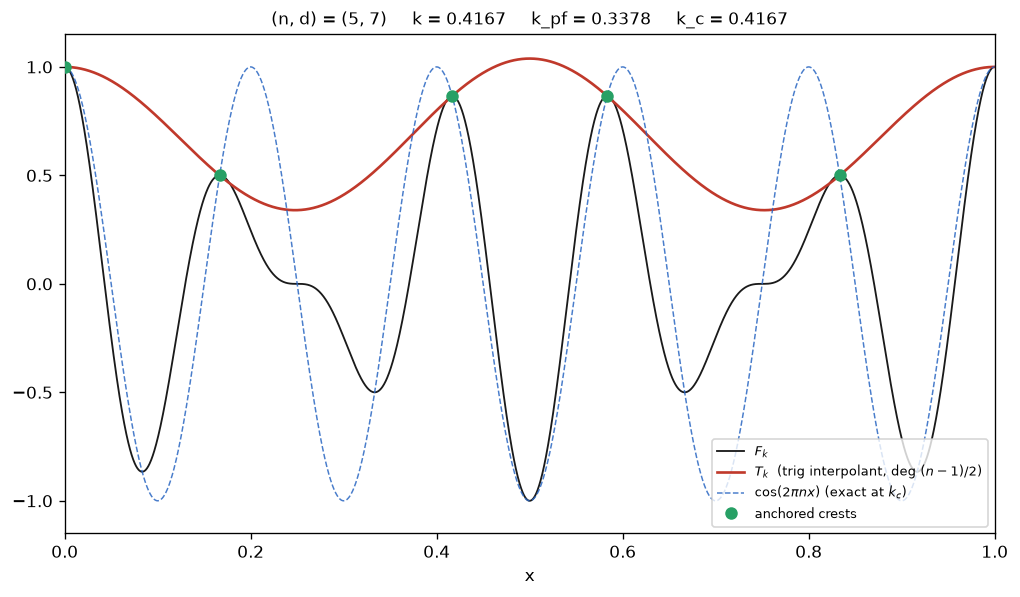

In [ ]:
# The same initial plot as running T_k(x).py with its default parameters.
plot_selector_curves(n=5, d=7, k=5 / 12)


In [ ]:
n_control = widgets.Dropdown(
    options=(3, 5, 7, 9, 11, 13, 15), value=5, description="n",
)
d_control = widgets.IntSlider(
    value=7, min=4, max=100, step=1, description="d", continuous_update=False,
)
k_control = widgets.FloatSlider(
    value=5 / 12, min=0.0, max=1.0, step=0.0005, description="k",
    readout_format=".4f", continuous_update=True,
    layout=widgets.Layout(width="900px"),
    style={"description_width": "30px"},
)

frequency_controls = widgets.HBox([n_control, d_control])
controls = widgets.VBox([frequency_controls, k_control])
output = widgets.interactive_output(
    plot_selector_curves, {"n": n_control, "d": d_control, "k": k_control}
)
display(controls, output)


## 3. From visualization to a certified trigger

The selector curve is descriptive. The certified thresholdless trigger instead combines stationarity, crest direction, positivity, and an integer residue gate. At an event $x$, latch

$$i=\left\lfloor nx+\frac12\right\rfloor,\qquad p=\left\lfloor dx+\frac12\right\rfloor,$$

and accept the crest precisely when

$$F_k'(x)=0,\quad F_k''(x)<0,\quad F_k(x)>0,\quad |np-di|\leq\frac{n-1}{2}.$$

This gate uses only zero comparisons and integer arithmetic. See Proposition 4.3 of the companion note for the proof.

### Suggested experiments

1. Set $k$ close to $k_c=n/(n+d)$ and watch the green crest tops meet the dashed slow wave.
2. Move $k$ toward either endpoint and observe $T_k$ flatten toward the constant $1$.
3. Try $(n,d)=(7,50)$ or $(3,100)$ and watch the interpolant follow the anchored crest tops through the dense fast oscillations.
